# Import thư viện


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Kiểm tra GPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Tiền xử lý ảnh 

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Load dataset

In [4]:
from torchvision import datasets

dataset_path = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset"

dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)


Total images: 17092
Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [5]:
from torch.utils.data import random_split

dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 11964
Validation: 2563
Test: 2565


# Dataloader

In [6]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
class_names = dataset.classes

print(class_names)

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


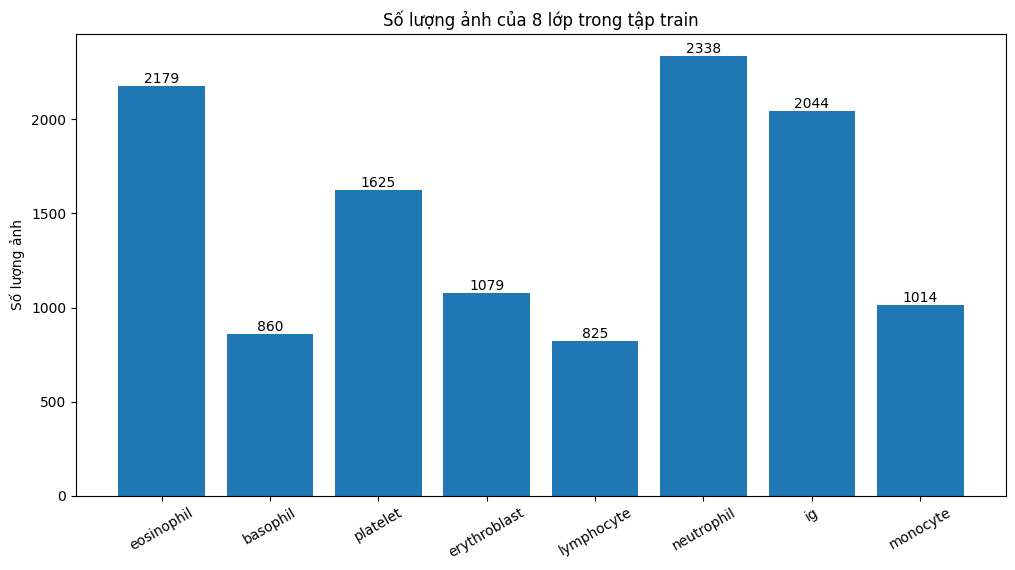

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

train_labels = [dataset.targets[i] for i in train_dataset.indices]

# đếm số lượng mỗi class
label_count = Counter(train_labels)

class_names = dataset.classes

labels = [class_names[i] for i in label_count.keys()]
counts = list(label_count.values())

plt.figure(figsize=(12,6))

bars = plt.bar(labels, counts)

plt.title("Số lượng ảnh của 8 lớp trong tập train")
plt.ylabel("Số lượng ảnh")

plt.xticks(rotation=30)

# in số lượng lên trên mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

# sample img

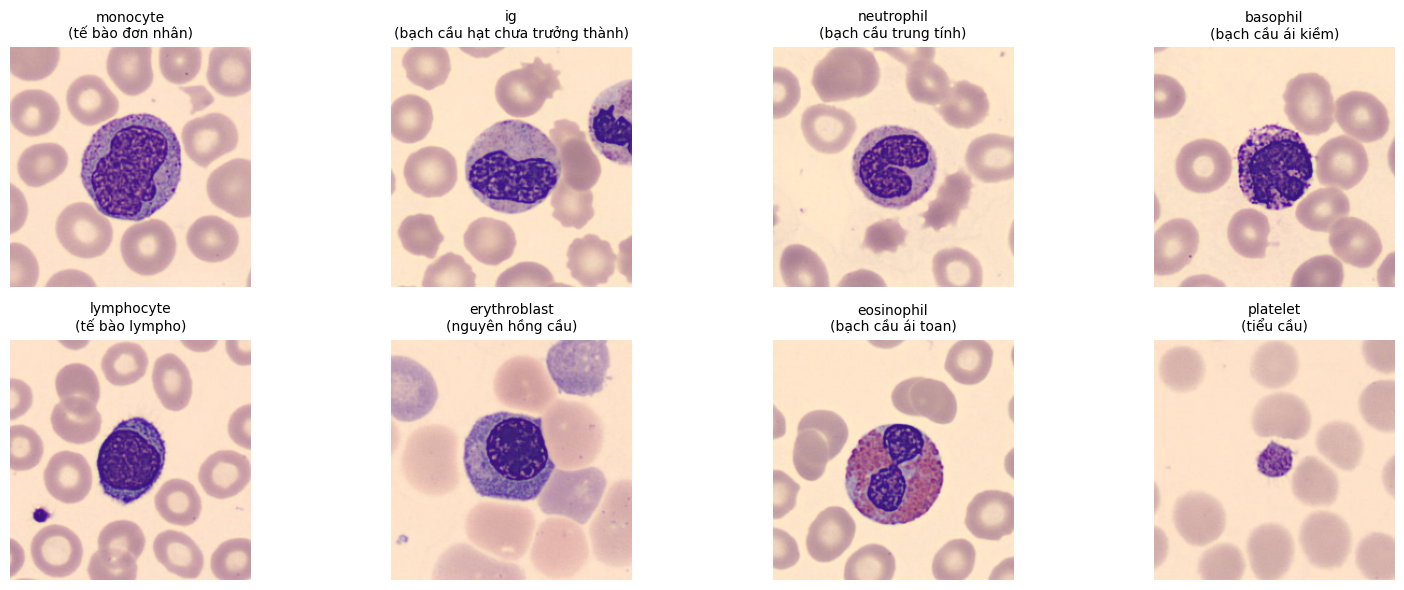

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset"

# Mapping Anh -> Việt
class_vi = {
    "neutrophil": "bạch cầu trung tính",
    "eosinophil": "bạch cầu ái toan",
    "basophil": "bạch cầu ái kiềm",
    "lymphocyte": "tế bào lympho",
    "monocyte": "tế bào đơn nhân",
    "ig": "bạch cầu hạt chưa trưởng thành",
    "erythroblast": "nguyên hồng cầu",
    "platelet": "tiểu cầu"
}

samples = []

# duyệt từng lớp
for cls in os.listdir(dataset_path):

    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):

        images = os.listdir(cls_path)

        img_name = random.choice(images)

        img_path = os.path.join(cls_path, img_name)

        samples.append((cls, img_path))

plt.figure(figsize=(16,6))

for i, (label, img_path) in enumerate(samples):

    img = Image.open(img_path).convert("RGB")
    img = img.resize((224,224))

    plt.subplot(2,4,i+1)
    plt.imshow(img)

    
    title = f"{label}\n({class_vi.get(label,'')})"

    plt.title(title, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Load Alexnet pretrained

In [9]:
model = models.alexnet(pretrained=True)

# Đóng băng 
for param in model.parameters():
    param.requires_grad = False

# Thay thế lớp phân loại cuối cùng 
model.classifier[6] = nn.Linear(4096, 8)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 214MB/s]


# Loss & optimizer

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier[6].parameters(), 
    lr=0.00001  
)

# Train 

In [11]:
from tqdm import tqdm
import torch

epochs = 100
patience = 5

train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_acc = 0
counter = 0
def train_one_epoch():

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        loop.set_postfix(loss=loss.item(), acc=acc)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

# Validation

In [12]:
def validate():

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    return val_loss, val_acc

# Checkpoint + Early Stop

In [13]:
def save_checkpoint(epoch, val_acc):

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_accuracy': val_acc
    }, "alexnet_checkpoint.pth")

# Train model

In [14]:
for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # Train
    train_loss, train_acc = train_one_epoch()

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

    # Validation
    val_loss, val_acc = validate()

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        save_checkpoint(epoch, val_acc)

        print("Checkpoint saved")

    else:

        counter += 1
        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:

            print("Early stopping triggered")
            break


Epoch 1/100


100%|██████████| 374/374 [02:01<00:00,  3.07it/s, acc=25.5, loss=1.71]


Train Loss: 1.9716 | Train Acc: 25.48%
Val Loss: 1.7466 | Val Acc: 43.74%
Checkpoint saved

Epoch 2/100


100%|██████████| 374/374 [00:48<00:00,  7.66it/s, acc=43.6, loss=1.42]


Train Loss: 1.6525 | Train Acc: 43.57%
Val Loss: 1.5323 | Val Acc: 53.41%
Checkpoint saved

Epoch 3/100


...

Train Loss: 0.7258 | Train Acc: 74.95%
Val Loss: 0.5892 | Val Acc: 82.21%
No improvement (3/5)

Epoch 59/100


100%|██████████| 374/374 [00:51<00:00,  7.24it/s, acc=74.6, loss=0.85]


Train Loss: 0.7289 | Train Acc: 74.62%
Val Loss: 0.5858 | Val Acc: 82.17%
No improvement (4/5)

Epoch 60/100


100%|██████████| 374/374 [00:51<00:00,  7.22it/s, acc=75.1, loss=0.551]


Train Loss: 0.7167 | Train Acc: 75.13%
Val Loss: 0.5874 | Val Acc: 82.17%
No improvement (5/5)
Early stopping triggered


# Test

In [15]:
checkpoint = torch.load("/kaggle/working/alexnet_checkpoint.pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 83.98%


# Plot Train Loss

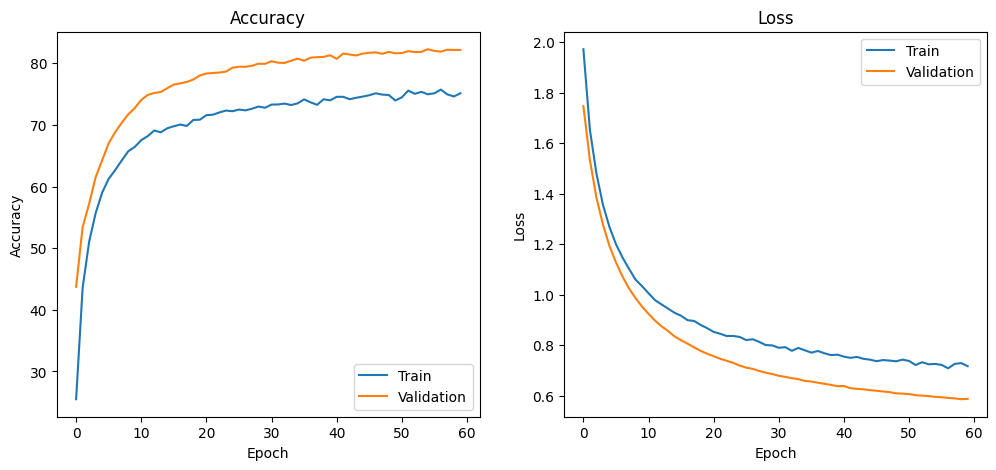

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# confusion matrix

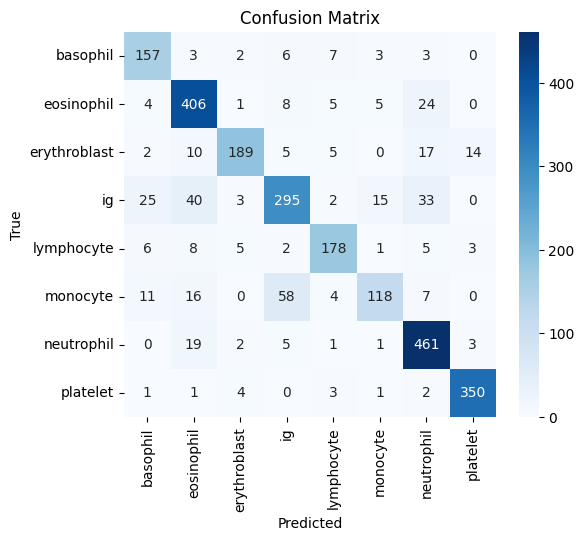

In [17]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

In [18]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [19]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.76      0.87      0.81       181
  eosinophil       0.81      0.90      0.85       453
erythroblast       0.92      0.78      0.84       242
          ig       0.78      0.71      0.74       413
  lymphocyte       0.87      0.86      0.86       208
    monocyte       0.82      0.55      0.66       214
  neutrophil       0.84      0.94      0.88       492
    platelet       0.95      0.97      0.96       362

    accuracy                           0.84      2565
   macro avg       0.84      0.82      0.83      2565
weighted avg       0.84      0.84      0.84      2565



# Predict

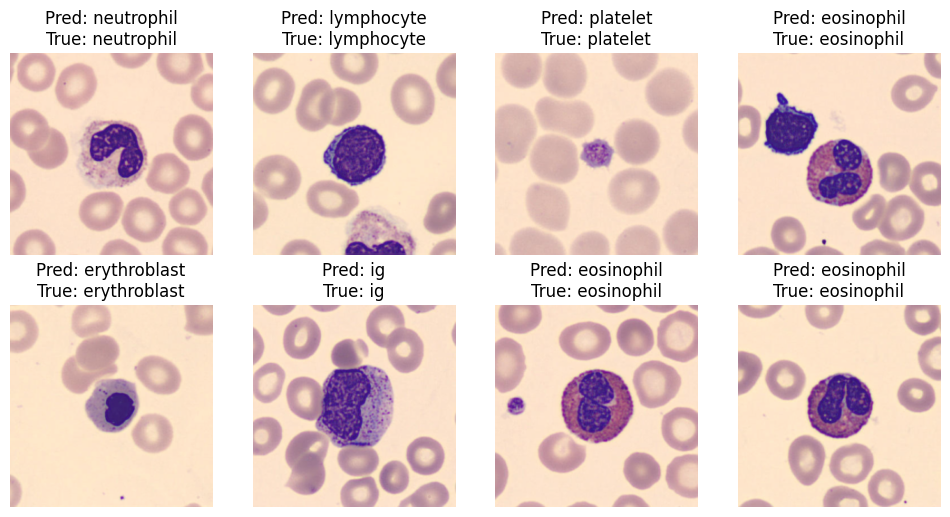

In [20]:
import numpy as np
import matplotlib.pyplot as plt

dataiter = iter(test_loader)

images, labels = next(dataiter)

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

_, preds = torch.max(outputs,1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12,6))

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i].numpy().transpose((1,2,0))
    img = std * img + mean
    img = np.clip(img,0,1)

    plt.imshow(img)

    plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}")

    plt.axis("off")

plt.show()